### Imports

In [1]:
import numpy as np
from matplotlib.patches import Ellipse, Rectangle, Polygon
from matplotlib.widgets import Slider
import matplotlib#; matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
from futhark_server import Server 


### Helpers

In [2]:

def cov3d(sx, sy, sz, rx, ry, rz):
    R = rot_mat(rx,ry,rz)
    S = np.array([
        [sx,0,0],
        [0,sy,0],
        [0,0,sz]
    ])
    return (R@S)@((R@S).T)

# get a rotation matrix from roll, pitch, and yaw
def rot_mat(rx_deg, ry_deg, rz_deg):
    rx, ry, rz = np.radians(rx_deg), np.radians(ry_deg), np.radians(rz_deg)
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(rx), -np.sin(rx)],
        [0, np.sin(rx),  np.cos(rx)]
    ])
    Ry = np.array([
        [ np.cos(ry), 0, np.sin(ry)],
        [0, 1, 0],
        [-np.sin(ry), 0, np.cos(ry)]
    ])
    Rz = np.array([
        [np.cos(rz), -np.sin(rz), 0],
        [np.sin(rz),  np.cos(rz), 0],
        [0,0,1]
    ])
    return Rz @ Rx @ Ry

def camera_orbit(rho, rx_deg, ry_deg, rz_deg, gx, gy, gz):
    # start rho away along +Z, looking at origin, with Y "up"
    R = rot_mat(rx_deg, ry_deg, rz_deg) 

    g = np.array([gx, gy, gz])

    offset = R @ np.array([0, 0, rho])
    eye = g + offset
    
    # camera basis = world basis rotated by the same R
    right   = R @ np.array([1, 0, 0])
    up      = R @ np.array([0, 1, 0])
    forward = R @ np.array([0, 0, 1])   # points from origin toward eye

    return np.array([
        [right[0], up[0], forward[0], eye[0]],
        [right[1], up[1], forward[1], eye[1]],
        [right[2], up[2], forward[2], eye[2]],
        [0, 0, 0, 1]
    ])

def camera_look_at_origin(cx, cy, cz):
    target = np.array([0,0,0]) # origin
    eye = np.array([cx,cy,cz])
    forward = target - eye
    forward /= np.linalg.norm(forward)
    
    # pick an up vector that isn't parallel to forward
    up = np.array([0.0, -1.0, 0.0])
    if abs(np.dot(forward, up)) > 0.999:
        up = np.array([-1.0, 0.0, 0.0])  # fall back to Y-up at poles
    
    right = np.cross(forward, up);  right /= np.linalg.norm(right)
    up = np.cross(right, forward);   up /= np.linalg.norm(up)
    return np.array([
        [right[0], up[0], -forward[0], cx],
        [right[1], up[1], -forward[1], cy],
        [right[2], up[2], -forward[2], cz],
        [0,    0,    0,    1 ]
    ])


# Claude-generated function
def project_point(p_world, cam_mat, f, W, ortho_view_box=0.0):
    """Project a 3D world point to pixel coordinates."""
    world_to_cam = np.linalg.inv(cam_mat)
    p = world_to_cam @ np.array([*p_world, 1.0])
    depth = p[2]

    if ortho_view_box > 0:
        px = (p[0] / -ortho_view_box) * W/2 + W/2
        py = -(p[1] / -ortho_view_box) * W/2 + W/2
        return px, py

    px = (f * p[0] / depth) * W/2 + W/2
    py = -(f * p[1] / depth) * W/2 + W/2
    return px, py

# Claude-generated function
def draw_axes_overlay(ax, cam_mat, f, W, origin=(0,0,0), length=1, ortho_view_box=0.0):
    o = project_point(origin, cam_mat, f, W, ortho_view_box=ortho_view_box)
    if o is None:
        return
    for direction, color, label in [
        ([1,0,0], '#ff4444', 'X'),
        ([0,1,0], '#44ff44', 'Y'),
        ([0,0,1], '#4488ff', 'Z'),
    ]:
        tip = [origin[i] + length * direction[i] for i in range(3)]
        t = project_point(tip, cam_mat, f, W, ortho_view_box=ortho_view_box)

        if t is None:
            continue
        ax.annotate('', xy=t, xytext=o,
            arrowprops=dict(arrowstyle='->', color=color, lw=2, mutation_scale=15))
        
        dx, dy = t[0] - o[0], t[1] - o[1]
        norm = (dx**2 + dy**2) ** 0.5
        pad = 15  # pixels beyond the arrow tip
        if norm > 0:
            label_pos = (t[0] + dx/norm * pad, t[1] + dy/norm * pad)
        else:
            label_pos = t

        ax.text(
            label_pos[0],
            label_pos[1],
            label,
            color=color,
            fontsize=11,
            fontweight='bold',
            ha='center',
            va='center')


### Record Objects

In [3]:
class Gaussian:
    def __init__(self, mean, scale, rot):
        self.mean = mean
        self.cov = cov3d(*scale, *rot)
        print(self.cov)
        self.conic = np.linalg.inv(self.cov)
        self.coef = 1 / ((2*np.pi)**1.5 * np.linalg.det(self.cov)**0.5)


class Volume_Renderer:
    def __init__(self, server, W, focal_length, delta, max_depth):
        self.server, self.W, self.focal_length, self.delta, self.max_depth = server, W, focal_length, delta, max_depth

    def render(self, gaussian, cam2world, ax, ortho_view_box=0.0, ax_origin=(0,0,0), title=None):
        self.server.put_value('W', np.int64(self.W))
        self.server.put_value('camera', cam2world.astype(np.float32))
        self.server.put_value('focal_length', np.float32(self.focal_length))
        self.server.put_value('delta', np.float32(self.delta))
        self.server.put_value('max_depth', np.float32(self.max_depth))
        self.server.put_value('mean', np.array(gaussian.mean, dtype=np.float32))
        self.server.put_value('coef', np.float32(gaussian.coef))
        self.server.put_value('conic', gaussian.conic.astype(np.float32))
        self.server.put_value('ortho_view_box', np.float32(ortho_view_box))

        self.server.cmd_call('rasterize', 'res', 'W', 'focal_length', 'camera', 'coef', 'conic', 'mean', 'delta', 'max_depth', 'ortho_view_box')
        res = self.server.get_value('res')

        self.server.cmd_free('res')
        self.server.cmd_free('camera')
        self.server.cmd_free('focal_length')
        self.server.cmd_free('delta')
        self.server.cmd_free('W')
        self.server.cmd_free('max_depth')
        self.server.cmd_free('coef')
        self.server.cmd_free('conic')
        self.server.cmd_free('mean')
        self.server.cmd_free('ortho_view_box')

        ax.cla()
        draw_axes_overlay(ax, cam2world, self.focal_length, self.W, origin=ax_origin, ortho_view_box=ortho_view_box)
        ax.imshow(1 - res, cmap='gray', vmin=0, vmax=1, origin='upper')
        if ortho_view_box > 0:
            ticks = np.linspace(0, self.W, 5)
            labels = np.linspace(-ortho_view_box, ortho_view_box, 5)
            ax.set_xticks(ticks)
            ax.set_xticklabels([f'{v:.2f}' for v in labels])
            ax.set_yticks(ticks)
            ax.set_yticklabels([f'{v:.2f}' for v in labels[::-1]])  # y flipped: origin='upper'
        else:
            ax.set_xticks([])
            ax.set_yticks([])

        if name:
            ax.set_title(title)

        

        
        


### Generate Plot

[[0.0144 0.     0.    ]
 [0.     0.0625 0.    ]
 [0.     0.     0.25  ]]


/tmp/ipykernel_260859/2363477004.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


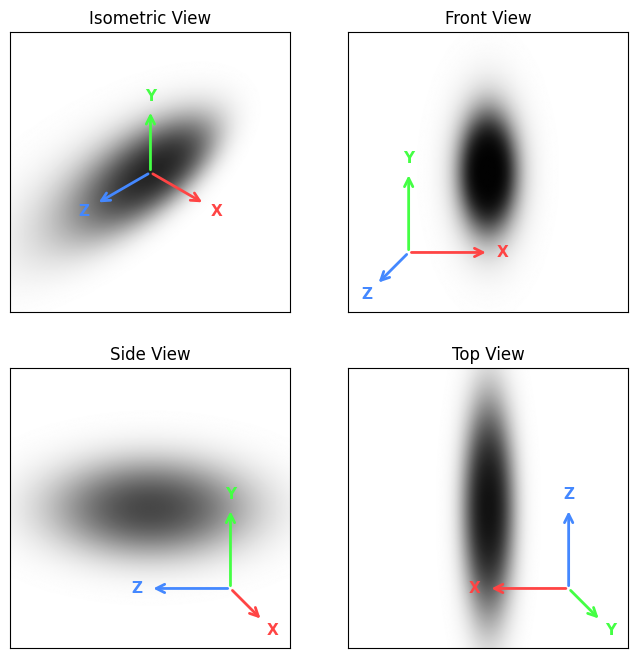

In [4]:
server = Server('./volumetric')

gaussian = Gaussian(
    mean=[0,0,0], 
    scale=[0.12, 0.25, 0.5],
    rot=[0,0,0]
)

vrender = Volume_Renderer(server=server, W=300, focal_length=2, delta=0.05, max_depth=10)

rho = 2.5
sq = np.sqrt((rho**2)/3)

nudge_deg = 0
target = np.array([0,0,0])
iso_cam_pos = np.array([sq, sq, sq]) + target

cams = [
    camera_look_at_origin(*iso_cam_pos),
    camera_orbit(rho, nudge_deg,0,-180, *target),
    camera_orbit(rho, 180,90,nudge_deg, *target),
    camera_orbit(rho, -90 + nudge_deg,0,0, *target) 
]

names = [
    'Isometric View',
    'Front View',
    "Side View",
    "Top View"
]

fig,axes = plt.subplots(
    2,2, 
    figsize=(8,8), 
    #dpi=1200
    )
ortho_box = 1.2
ax_origin=(-1, -1, -1)

# for cam, ax in zip(cams, axes[0]):
#     vrender.render(gaussian, cam, ax, ortho_view_box=ortho_box,ax_origin=ax_origin)

for cam, ax, name in zip(cams[:2], axes[0], names[:2]):
    vrender.render(gaussian, cam, ax,ax_origin=ax_origin, title=name)
for cam, ax, name in zip(cams[2:], axes[1], names[2:]):
    vrender.render(gaussian, cam, ax,ax_origin=ax_origin, title=name)

fig.show()